In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import plotly.express as px

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

In [8]:
# Definición de ruta
file_path = '../../data/raw/dataset_refrigeracion.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Dataset cargado exitosamente. Formato: {df.shape}")
else:
    print("Error: El archivo no existe en la ruta especificada.")

# Resumen estadístico inicial
display(df.describe())

Dataset cargado exitosamente. Formato: (1872000, 21)


,T_amb,T_set,T_cab,T_evap_sat,T_cond_sat,P_suc_bar,P_dis_bar,N_comp_Hz,SH_K,P_comp_W,Q_evap_W,COP,frost_level,T_cab_meas,valve_open,time_min,run_id,fault_id,door_open,defrost_on
count,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06
mean,2.502810e+01,3.220848e+00,2.131217e+01,1.613717e+01,3.326359e+01,4.957957e+00,8.185168e+00,7.650492e+01,7.297271e+00,5.178258e+02,3.888621e+02,4.641907e+00,6.018202e-02,2.131302e+01,4.610819e-01,7.195000e+02,6.495000e+02,6.000000e+00,4.831944e-02,3.399145e-02
std,5.234617e+00,1.021385e+00,7.061757e+00,1.327970e+01,5.649930e+00,1.461210e+00,1.505371e+00,1.805654e+01,1.958237e+00,1.591568e+02,3.855537e+02,1.108437e+00,2.377869e-01,7.077854e+00,5.874712e-02,4.156922e+02,3.752777e+02,3.741658e+00,2.144404e-01,1.812072e-01
min,1.093664e+01,1.506844e+00,-1.686483e+00,-4.536191e+01,1.618393e+01,4.695570e-01,4.493195e+00,0.000000e+00,4.522527e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.667282e+00,2.293190e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.126294e+01,2.298816e+00,1.762674e+01,1.400686e+01,2.922573e+01,4.329147e+00,7.067831e+00,7.483404e+01,5.942414e+00,4.555741e+02,0.000000e+00,5.000000e+00,0.000000e+00,1.762915e+01,4.244928e-01,3.597500e+02,3.247500e+02,3.000000e+00,0.000000e+00,0.000000e+00
50%,2.499133e+01,3.215166e+00,2.081207e+01,1.738082e+01,3.320422e+01,4.828974e+00,8.035276e+00,8.279456e+01,6.282454e+00,5.371618e+02,3.562177e+02,5.000000e+00,0.000000e+00,2.074392e+01,4.915264e-01,7.195000e+02,6.495000e+02,6.000000e+00,0.000000e+00,0.000000e+00
75%,2.878534e+01,4.104362e+00,2.555930e+01,2.259967e+01,3.725473e+01,5.711263e+00,9.157249e+00,8.700000e+01,8.516908e+00,5.916144e+02,6.081197e+02,5.000000e+00,0.000000e+00,2.562239e+01,5.017276e-01,1.079250e+03,9.742500e+02,9.000000e+00,0.000000e+00,0.000000e+00
max,3.924128e+01,4.998877e+00,4.332525e+01,4.283289e+01,5.141683e+01,1.097812e+01,1.450918e+01,8.700000e+01,1.502270e+01,1.743657e+03,2.656341e+03,5.000000e+00,1.200000e+00,4.332275e+01,5.443242e-01,1.439000e+03,1.299000e+03,1.200000e+01,1.000000e+00,1.000000e+00


In [21]:
#Verificar si hay valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
# Verificar tipos de datos
print("\nTipos de datos por columna:")
print(df.dtypes)

Valores nulos por columna:
T_amb          0
T_set          0
T_cab          0
T_evap_sat     0
T_cond_sat     0
P_suc_bar      0
P_dis_bar      0
N_comp_Hz      0
SH_K           0
P_comp_W       0
Q_evap_W       0
COP            0
frost_level    0
T_cab_meas     0
valve_open     0
time_min       0
run_id         0
fault          0
fault_id       0
door_open      0
defrost_on     0
dtype: int64

Tipos de datos por columna:
T_amb          float64
T_set          float64
T_cab          float64
T_evap_sat     float64
T_cond_sat     float64
P_suc_bar      float64
P_dis_bar      float64
N_comp_Hz      float64
SH_K           float64
P_comp_W       float64
Q_evap_W       float64
COP            float64
frost_level    float64
T_cab_meas     float64
valve_open     float64
time_min         int64
run_id           int64
fault              str
fault_id         int64
door_open        int64
defrost_on       int64
dtype: object


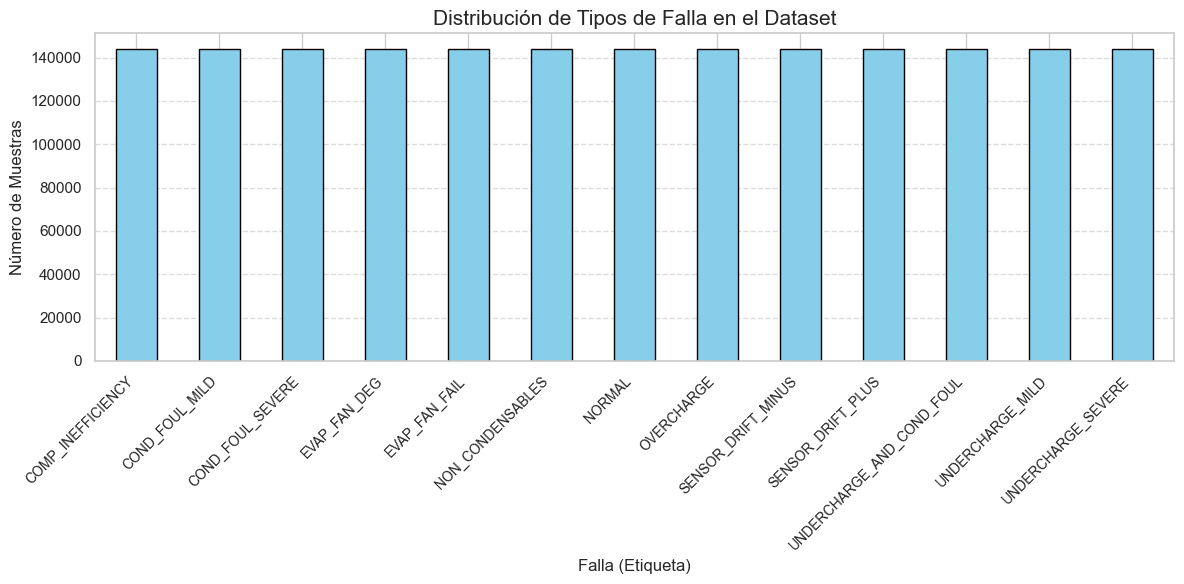

In [9]:
plt.figure(figsize=(12, 6))
# Usamos 'fault' para legibilidad en el EDA
df['fault'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Distribución de Tipos de Falla en el Dataset', fontsize=15)
plt.xlabel('Falla (Etiqueta)', fontsize=12)
plt.ylabel('Número de Muestras', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

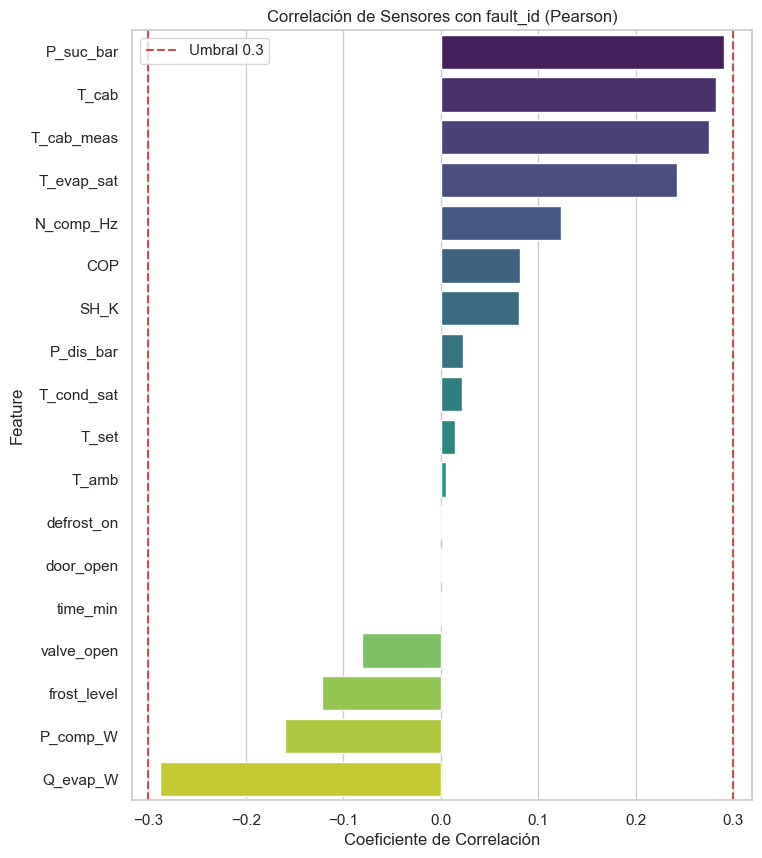

In [10]:
# Matriz de correlación numérica
corr_matrix = df.select_dtypes(include='number').corr()

fault_corr = corr_matrix['fault_id'].drop(['fault_id', 'run_id'], errors='ignore').sort_values(ascending=False)

# Visualización del Ranking de Importancia Lineal
plt.figure(figsize=(8, 10))
sns.barplot(x=fault_corr.values, y=fault_corr.index, hue=fault_corr.index, palette='viridis', legend=False)
plt.title('Correlación de Sensores con fault_id (Pearson)')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Feature')
plt.axvline(x=0.3, color='r', linestyle='--', label='Umbral 0.3')
plt.axvline(x=-0.3, color='r', linestyle='--')
plt.legend()
plt.show()

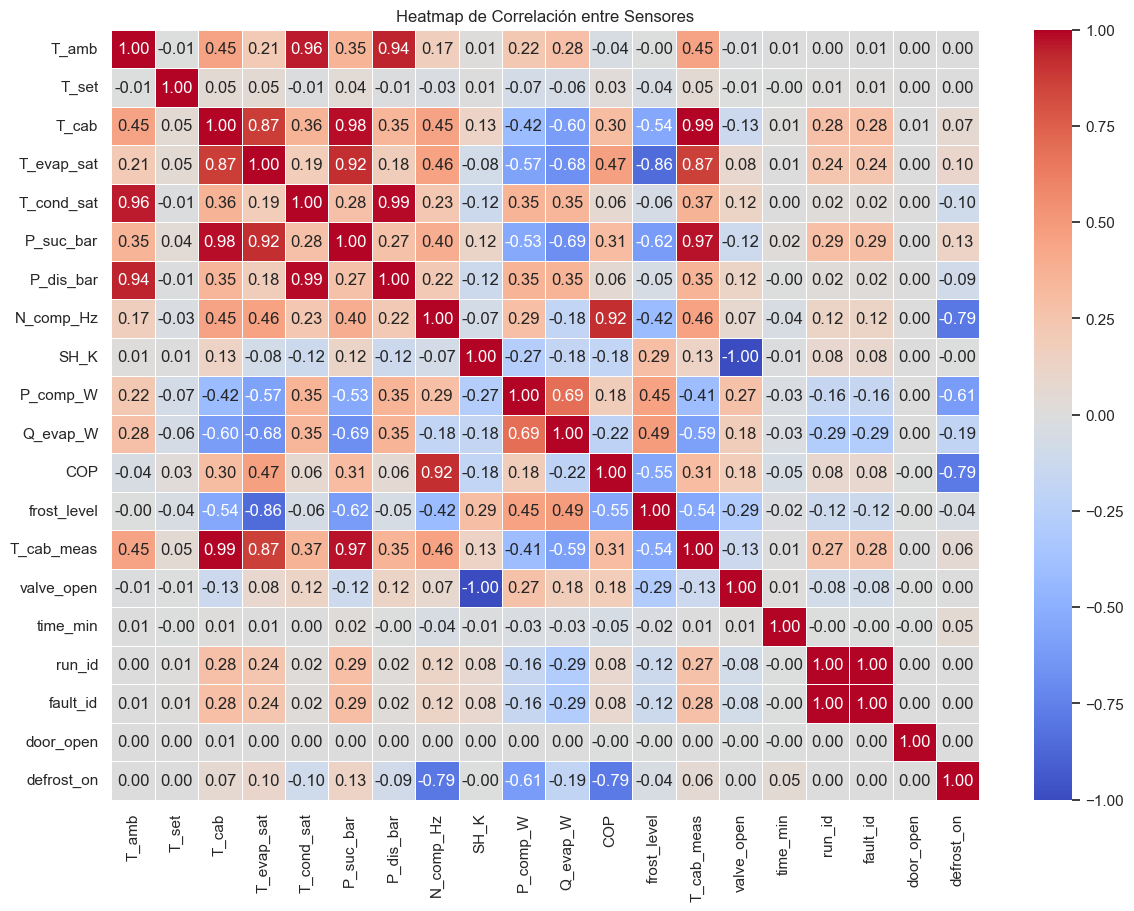

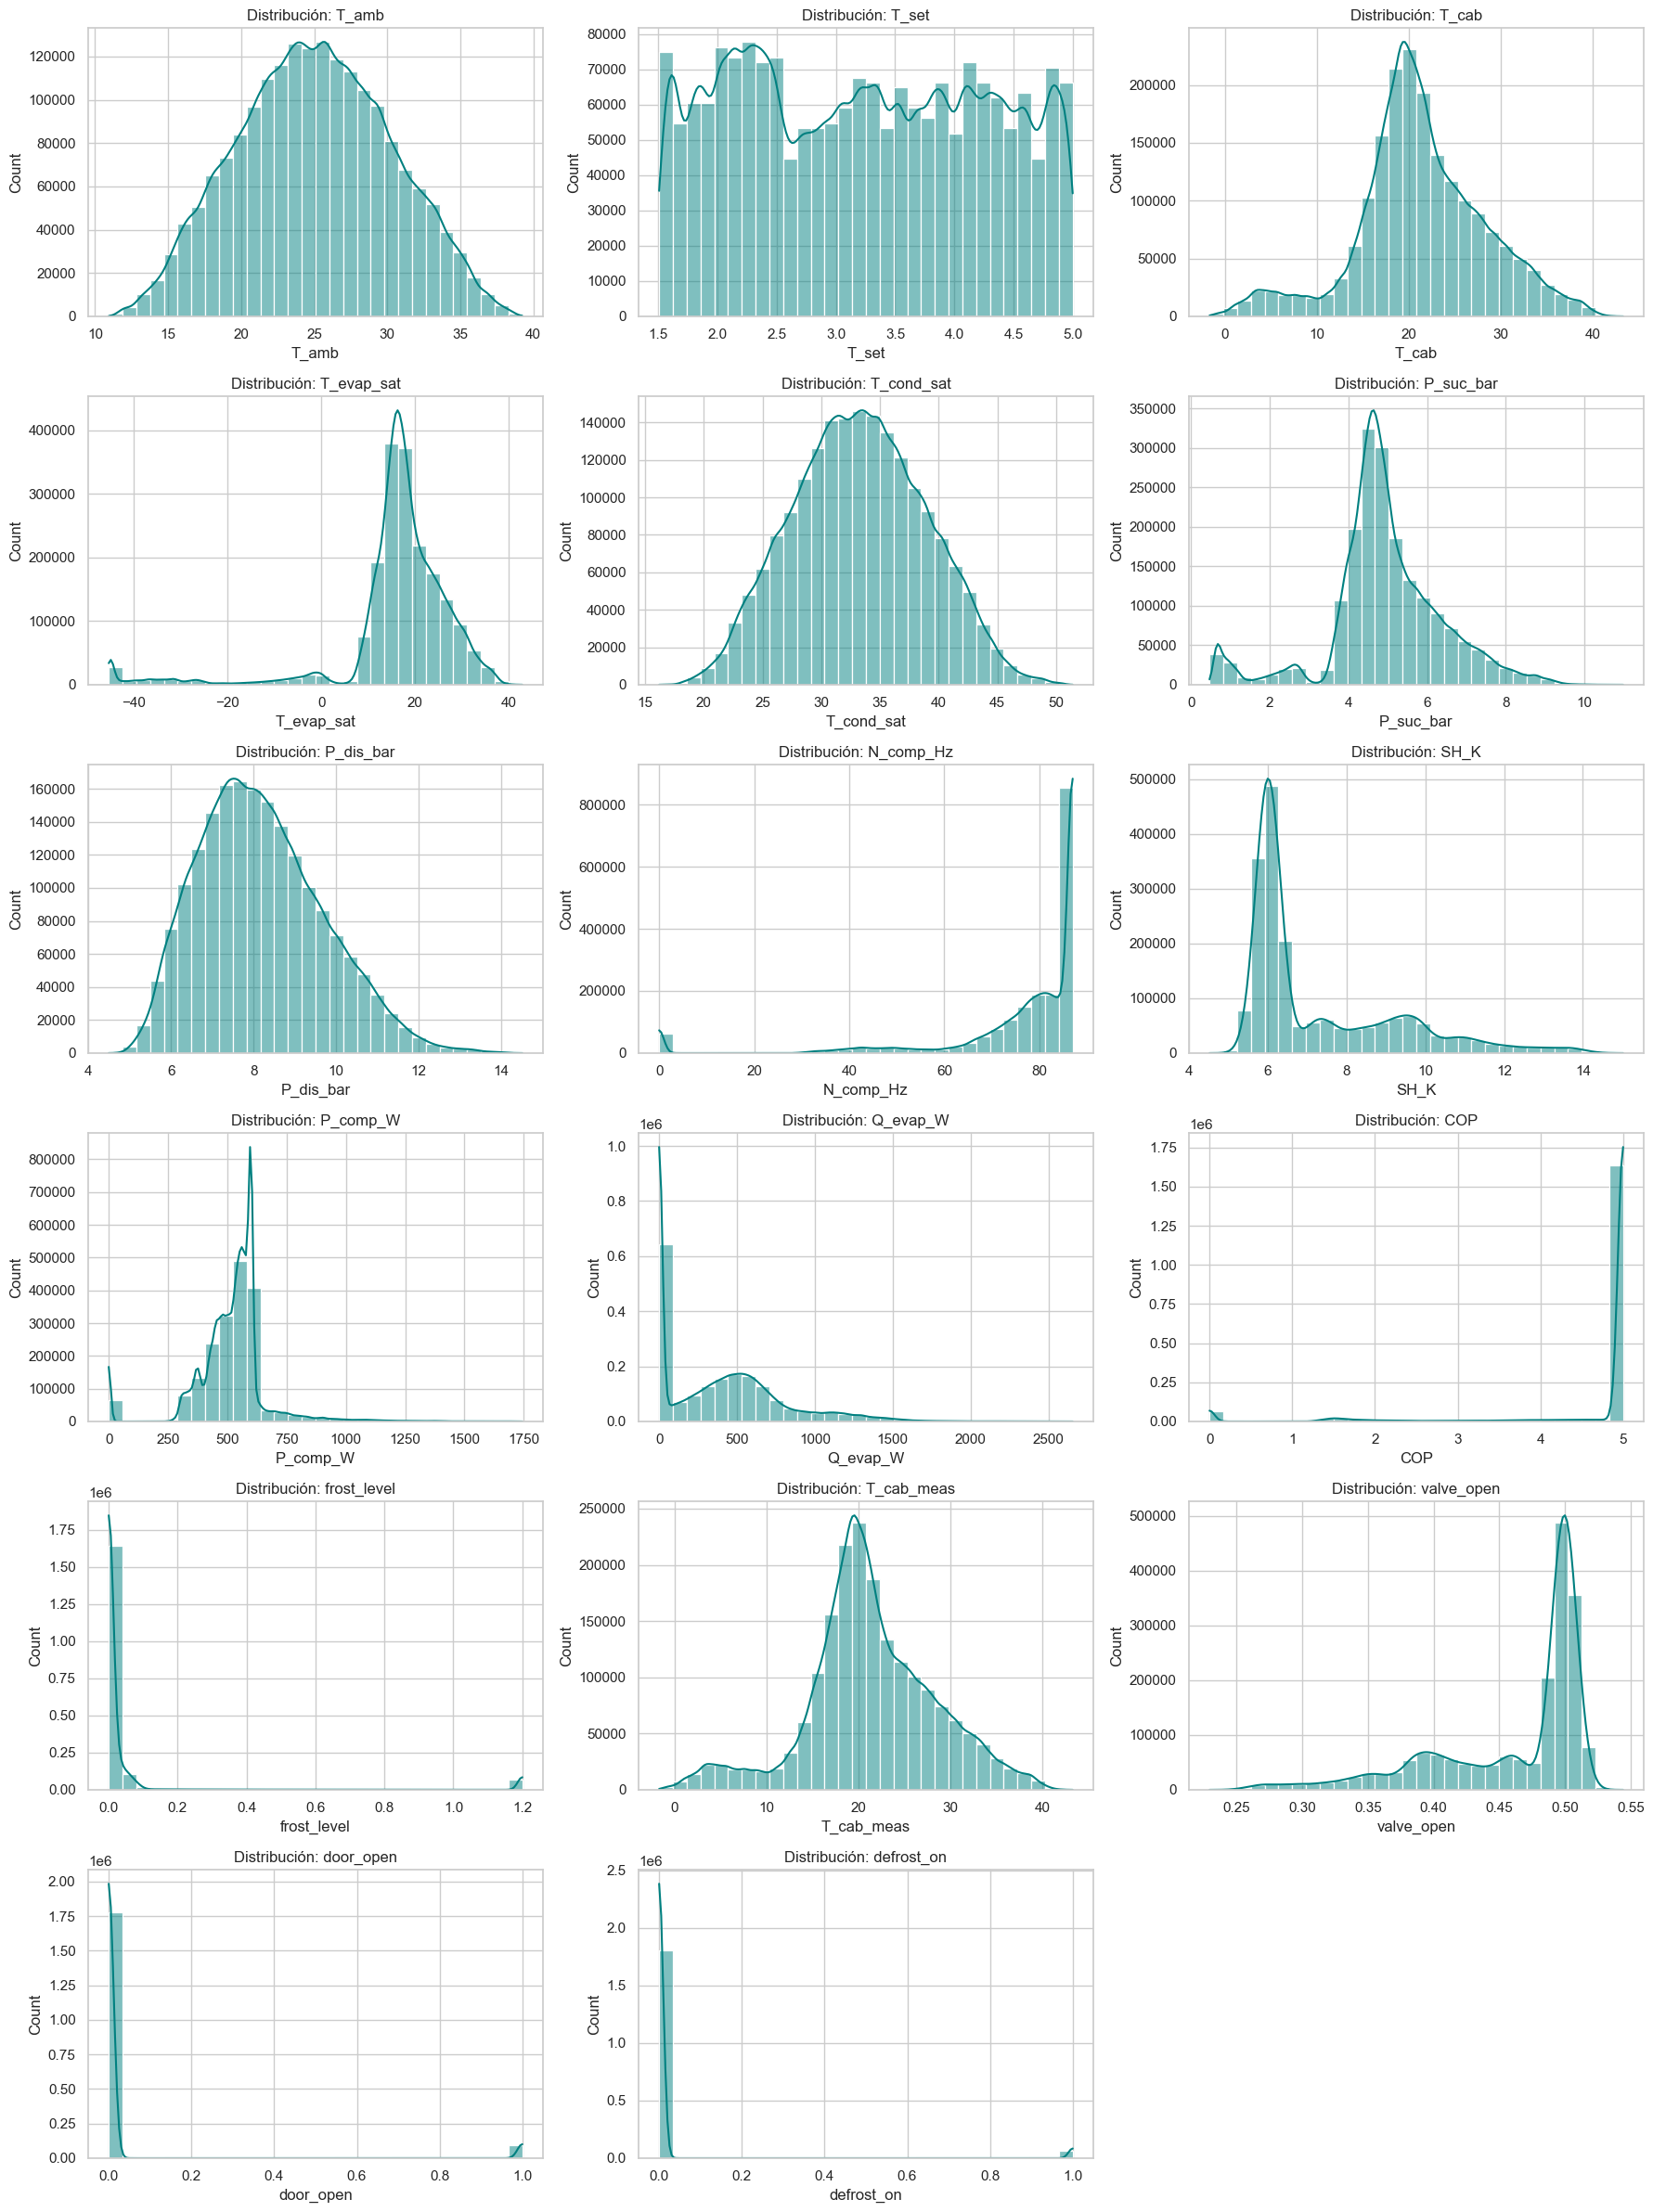

In [11]:
# Mapa de calor de colinealidad
plt.figure(figsize=(14, 10))
core_cols = df.select_dtypes(include='number').columns
corr = df[core_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=.5)
plt.title('Heatmap de Correlación entre Sensores')
plt.show()

# Distribuciones individuales
exclude = ['run_id', 'time_min', 'fault_id', 'fault']
numerical_features = [c for c in df.select_dtypes(include='number').columns if c not in exclude]

num_rows = math.ceil(len(numerical_features) / 3)
fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución: {feature}')

for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [12]:
# Selección de fallas representativas para comparar firmas térmicas
faults_to_compare = ['NORMAL', 'COND_FOUL_SEVERE', 'UNDERCHARGE_SEVERE', 'NON_CONDENSABLES']
run_ids_to_plot = [df[df['fault'] == f]['run_id'].iloc[0] for f in faults_to_compare]
df_plot = df[df['run_id'].isin(run_ids_to_plot)]

# Visualización de Temperatura de Cabina
fig1 = px.line(df_plot, x='time_min', y='T_cab', color='fault',
              title='Firma Térmica (T_cab) según tipo de Falla')
fig1.show()

# Visualización de Consumo Eléctrico
fig2 = px.line(df_plot, x='time_min', y='P_comp_W', color='fault',
              title='Consumo del Compresor (P_comp_W) según tipo de Falla')
fig2.show()

# Ingeniería de Características Basada en Domain Knowledge

Transformación de los datos crudos de los sensores en indicadores basados en variables físicas introducidas con domain knowledge. Estas variables están diseñadas para capturar las ineficiencias del ciclo de refrigeración que un sensor individual no puede ver por sí solo.

---

## Análisis de Diferenciales Térmicos (Lifts & Approach)
El rendimiento de una nevera depende de la diferencia de temperatura entre sus focos:

* **`T_lift` / `T_spread`**: Representa el "esfuerzo" total del sistema ($T_{cond} - T_{evap}$). Un aumento excesivo indica que el compresor está trabajando más de lo normal.
* **`T_cond_approach`**: Es la diferencia entre la condensación y el ambiente. 
    * *Diagnóstico:* Si este valor es muy alto, el **condensador está sucio** o el ventilador externo falla (no puede evacuar calor).
* **`T_error`**: Desviación respecto al set-point de la cabina.



---

## Indicadores de Compresión y Eficiencia
Evaluamos la salud mecánica del compresor y la termodinámica del refrigerante:

* **`Eff_vol` (Eficiencia Volumétrica)**: Ratio de temperaturas de saturación en Kelvin. Es un indicador clave de la salud interna del compresor.
* **`P_ratio` / `pressure_ratio`**: La relación entre la presión de descarga y succión. Si es muy alta, el compresor sufre estrés mecánico.
* **`specific_work`**: Energía consumida por cada unidad de calor extraída. Un aumento delata la degradación del sistema.

---

##  Detección de Anomalías Específicas
Hemos creado variables para "cazar" fallas difíciles:

### Firma de Incondensables (`P_dis_error`)
Calcula la desviación entre la presión de descarga real y la presión teórica de saturación. 
> **Física:** Si hay aire en el circuito, la presión sube por encima de lo que dice la tabla del refrigerante (Ley de Dalton). Este es el predictor principal para la **Clase 11**.

### Índice de Eficiencia Energética (`EEI` / `Q_est`)
Relaciona los vatios consumidos con la capacidad de enfriamiento real. 
* **`Thermal_Load_Index`**: Combina el salto térmico con el ratio de presiones para identificar si la cabina está sobrecargada o si el sistema ha perdido eficiencia.

---

## Estabilidad y Derivadas
* **`T_cab_grad`**: Detecta qué tan rápido baja la temperatura.
* **`P_dis_volatility`**: Mide si la presión de descarga es estable. Una presión "nerviosa" suele indicar problemas en la válvula de expansión o carga crítica.

In [13]:
def extract_physics_features(df):
    df = df.copy()
   
    # Diferenciales térmicos
    df['T_error'] = df['T_cab'] - df['T_set']
    df['T_lift'] = df['T_cond_sat'] - df['T_evap_sat']
    # Si el condensador está sucio, la temperatura de saturación (T_cond_sat) se aleja mucho de la ambiente
    df['T_cond_approach'] = df['T_cond_sat'] - df['T_amb'] 
    df['T_spread'] = df['T_cond_sat'] - df['T_evap_sat']
    df['T_cab_meas_diff'] = df['T_cab'] - df['T_cab_meas'] 

    # Presiones y potencia
    df['P_ratio'] = df['P_dis_bar'] / (df['P_suc_bar'] + 0.1)
    df['Power_per_diff'] = df['P_comp_W'] / (df['T_lift'] + 0.1)

    # Eficiencia de transferencia: Vatios consumidos por cada grado de enfriamiento
    df['Q_est'] = df['P_comp_W'] / (df['T_cab'] - df['T_evap_sat'] + 1e-5)

    # Error de sensor 
    df['Sensor_error'] = df['T_cab'] - df['T_cab_meas'] 
    
    # Derivadas (Tendencias instantáneas)
    df['T_cab_grad'] = df.groupby('run_id')['T_cab'].diff().fillna(0)
    df['P_suc_rate'] = df.groupby('run_id')['P_suc_bar'].diff().fillna(0)

    df['Eff_vol'] = (df['T_evap_sat'] + 273.15) / (df['T_cond_sat'] + 273.15)
    df['P_suc_norm'] = df['P_suc_bar'] / df['T_amb']

    # Desviación de saturación (Crucial para detectar Aire/Incondensables - Clase 11)
    df['P_dis_error'] = df['P_dis_bar'] - (df['T_cond_sat'] * 0.25)

    # Diferencial de Subenfriamiento aproximado
    df['T_subcooling_approx'] = df['T_cond_sat'] - df['T_amb'] 
    # Relación Potencia-Presión
    df['Power_to_Pratio'] = df['P_comp_W'] / (df['P_ratio'] + 0.1)

    # Estabilidad de presión
    df['P_dis_volatility'] = df.groupby('run_id')['P_dis_bar'].transform(lambda x: x.rolling(window=5).std()).fillna(0)

    df["pressure_ratio"] = df["P_dis_bar"] / (df["P_suc_bar"] + 0.1)
    df["specific_work"] = df["P_comp_W"] / (df["Q_evap_W"]+ 0.1)
    df["cop_degradation"] = df["COP"] / df.groupby("run_id")["COP"].transform("max")

    # Índice de eficiencia energética: relación entre el esfuerzo eléctrico y la capacidad de absorber calor
    df['EEI'] = df['P_comp_W'] / (df['T_cab'] - df['T_evap_sat'] + 0.1)
    # Carga térmica relativa (basada en inercia de producto si aplica)
    df['Thermal_Load_Index'] = (df['T_cab'] - df['T_evap_sat']) * df['P_ratio']

    
    return df

df_phys = extract_physics_features(df)
df_phys = df_phys.sort_values(["run_id", "time_min"])

# Ingeniería de Características Temporales y Dinámicas

En sistemas de refrigeración, el estado actual de las variables no es suficiente para un diagnóstico preciso. Necesitamos capturar la **inercia térmica**, las **tendencias de presión** y la **estabilidad del sistema** mediante ventanas deslizantes (*rolling*) y retardos (*lags*).

---

## Análisis de Retardos y Tendencias (Lags & Deltas)
Para que el modelo "recuerde" el comportamiento previo y detecte cambios bruscos, implementamos:
* **Lags (5, 15, 45 min):** Capturan el estado pasado de la presión de descarga (`P_dis_bar`) y la temperatura del condensador (`T_cond_sat`).
* **Deltas:** Calculan la velocidad de cambio ($Valor_{actual} - Valor_{lag}$). 
    * *Utilidad:* Un delta de presión positivo muy alto indica un bloqueo repentino o una entrada de carga térmica masiva que el sistema aún no ha compensado.



---

## Estadísticos de Ventana Deslizante (Rolling Features)
Analizamos el comportamiento en ventanas de tiempo (15, 20 y 30 minutos) para filtrar el ruido y detectar patrones de inestabilidad:

* **Rolling Mean (Media Móvil):** Representa el nivel base de operación, eliminando fluctuaciones rápidas e irrelevantes.
* **Rolling Std (Desviación Móvil):** Mide la **volatilidad**. 
    * *Fisica del fallo:* Un condensador sucio o una carga de refrigerante incorrecta suelen presentar presiones mucho más oscilantes que un sistema en estado nominal.

---

## Indicadores de Estabilidad Avanzada
Hemos desarrollado métricas que normalizan la variabilidad para hacerla comparable entre distintos puntos de operación:

###  Coeficiente de Inestabilidad (`Pdis_instability_20`)
Se calcula como el ratio entre la desviación estándar y la media de la presión:
$$Pdis\_instability = \frac{\sigma(P_{dis})}{\mu(P_{dis})}$$

Permite comparar la inestabilidad de un sistema que trabaja a alta presión (verano) frente a uno de baja presión (invierno) de forma justa y proporcional.

### Volatilidad del Condensador (`cond_approach_std_20`)
Mide qué tan errática es la diferencia entre la temperatura de condensación y la ambiente. Es un predictor crítico de fallos mecánicos en el ventilador exterior o aletas obstruidas.



---

## Calidad de Datos y Limpieza
Para garantizar que el modelo de Machine Learning no reciba valores nulos o inconsistentes:
1. **Agrupación por `run_id`:** Los cálculos temporales se reinician en cada experimento, evitando "contaminación" entre diferentes ciclos.
2. **Backfill (`bfill`):** Rellena los huecos iniciales de las ventanas de tiempo para no perder los primeros minutos de cada arranque.
3. **Limpieza de NaNs:** Eliminamos filas donde los retardos largos (lags) no disponen de datos suficientes, asegurando que cada muestra tenga una firma temporal completa.

```python
# Estado actual del dataset procesado
print(f"Dataset final: {df_final.shape[1]} características preparadas para el modelo.")

In [14]:
def create_temporal_features(df):
    df = df.copy()
    lag_features = ["P_dis_bar", "T_cond_sat"]
    lags = [5, 15, 45]
    
    for feat in lag_features:
        for lag in lags:
            # En Pandas nuevo: .bfill() reemplaza a .fillna(method='bfill')
            df[f"{feat}_lag_{lag}"] = df.groupby("run_id")[feat].shift(lag).bfill()
            df[f"{feat}_delta_{lag}"] = df[feat] - df[f"{feat}_lag_{lag}"]
    
    for w in [15, 30]:
        # min_periods=1 asegura que calcule la métrica aunque haya pocos datos al inicio
        df[f"P_dis_roll_std_{w}"] = df.groupby("run_id")["P_dis_bar"].transform(
            lambda x: x.rolling(w, min_periods=1).std()
        ).fillna(0)
        
        df[f"EEI_roll_mean_{w}"] = df.groupby("run_id")["EEI"].transform(
            lambda x: x.rolling(w, min_periods=1).mean()
        ).bfill()

    return df


df_phys['P_dis_error_lag_100'] = df_phys.groupby("run_id")["P_dis_error"].shift(100)

def create_rolling_features(df, features, windows):
    for feature in features:
        for w in windows:
            roll = (
                df.groupby("run_id")[feature]
                  .rolling(w, min_periods=w//2)
            )
            df[f"{feature}_roll_std_{w}"] = df.groupby("run_id")[feature].transform(lambda x: x.rolling(w, min_periods=w//2).std())
            df[f"{feature}_roll_mean_{w}"] = roll.mean().reset_index(level=0, drop=True)
    return df

rolling_features = ["P_dis_bar", "T_cond_sat", "EEI"]
windows = [15, 30]

df_phys = create_rolling_features(df_phys, rolling_features, windows)
df_phys = create_temporal_features(df_phys)

# Estabilidad refinada de presión
df_phys["P_dis_bar_roll_std_20"] = df_phys.groupby("run_id")["P_dis_bar"].transform(
    lambda x: x.rolling(20, min_periods=10).std()
)

df_phys["P_dis_bar_roll_mean_20"] = df_phys.groupby("run_id")["P_dis_bar"].transform(
    lambda x: x.rolling(20, min_periods=10).mean()
)

df_phys["cond_approach_std_20"] = df_phys.groupby("run_id")["T_cond_approach"].transform(
    lambda x: x.rolling(20, min_periods=10).std()
)
df_phys["Pdis_instability_20"] = df_phys["P_dis_bar_roll_std_20"] / (df_phys["P_dis_bar_roll_mean_20"] + 1e-5)



# Limpieza final de NaNs generados por los nuevos lags
df_phys = df_phys.dropna(subset=[
    "Pdis_instability_20",
    "P_dis_bar_delta_15"
])

df_final = df_phys.copy()
print(f"Dataset procesado final: {df_final.shape}")

Dataset procesado final: (1860300, 74)


##  Detección de Incondensables (Aire en el circuito)

La **Clase 11 (NON-CONDENSABLES)** es una de las más difíciles de detectar porque no siempre bloquea el sistema, pero eleva drásticamente el consumo. 

* **Física del fallo:** El aire no se condensa en el condensador; se acumula en la parte superior, aumentando la presión de descarga de forma artificial (Ley de Dalton de las presiones parciales).
* **Métrica introducida:** `early_P_dis_error`. Al arrancar el sistema, el aire atrapado genera un "golpe" de presión inmediato. Calculando el error en los primeros 100 minutos, capturamos esta firma única antes de que el sistema intente estabilizarse térmicamente.

Calculando indicadores físicos...
         early_P_dis_error  mean_P_dis_bar
9                -0.257350        7.327239
10               -0.257350        7.327239
11               -0.257350        7.327239
12               -0.257350        7.327239
13               -0.257350        7.327239
...                    ...             ...
1871995          -0.270622        7.501217
1871996          -0.270622        7.501217
1871997          -0.270622        7.501217
1871998          -0.270622        7.501217
1871999          -0.270622        7.501217

[1860300 rows x 2 columns]
Index(['T_amb', 'T_set', 'T_cab', 'T_evap_sat', 'T_cond_sat', 'P_suc_bar',
       'P_dis_bar', 'N_comp_Hz', 'SH_K', 'P_comp_W', 'Q_evap_W', 'COP',
       'frost_level', 'T_cab_meas', 'valve_open', 'time_min', 'run_id',
       'fault', 'fault_id', 'door_open', 'defrost_on', 'T_error', 'T_lift',
       'T_cond_approach', 'T_spread', 'T_cab_meas_diff', 'P_ratio',
       'Power_per_diff', 'Q_est', 'Sensor_error', 'T_cab_gr

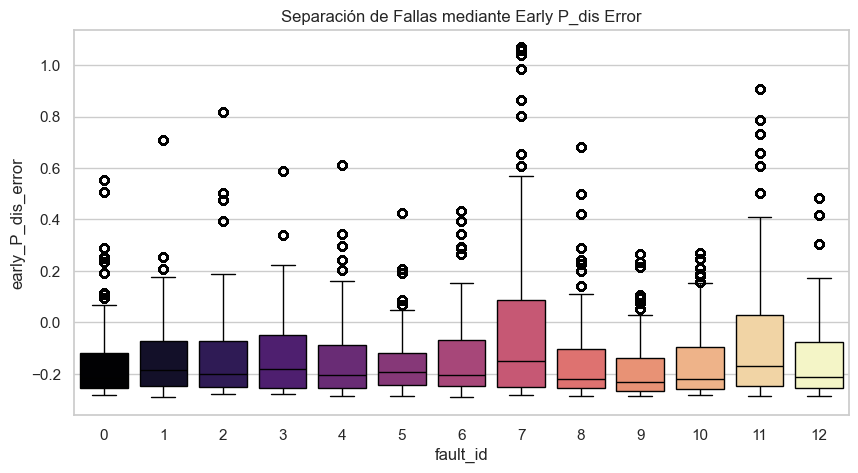

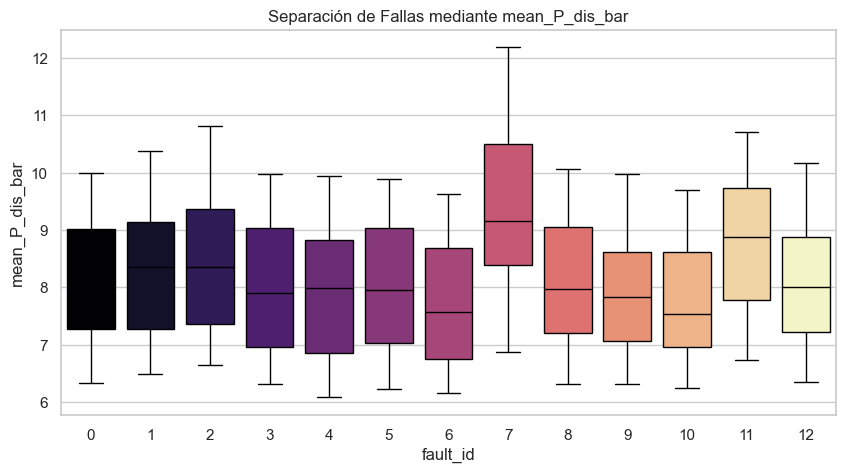

In [15]:
def physics_indicators(df):
    # Creamos un dataframe temporal para los cálculos por grupo (run_id)
    # Esto asegura que no mezclemos datos de diferentes experimentos
    phys = pd.DataFrame(index=df.index)
    
    # EARLY DISCHARGE ERROR (Firma de Incondensables)
    # Calculamos el error medio de presión de descarga SOLO en los primeros 100 minutos del ciclo.
    # Los incondensables (aire) causan picos de presión muy característicos al arrancar.
    phys['early_P_dis_error'] = df.groupby('run_id')['P_dis_error'].transform(lambda x: x.iloc[:100].mean())
    
    # MEAN DISCHARGE PRESSURE (Carga térmica media)
    # Promedio de presión de descarga en todo el ciclo.
    phys['mean_P_dis_bar'] = df.groupby('run_id')['P_dis_bar'].transform('mean')

    
    
    return phys

# --- EJECUCIÓN ---
print("Calculando indicadores físicos...")
physics_feats = physics_indicators(df_final)
print(physics_feats)
# Unimos los nuevos indicadores al dataframe principal evitando duplicados
cols_to_add = physics_feats.columns.difference(df_final.columns)
df_final = df_final.join(physics_feats[cols_to_add])
print(df_final.columns)

print(f"Se han añadido {len(cols_to_add)} nuevas columnas de indicadores expertos.")
print(f"Columnas añadidas: {list(cols_to_add)}")

# Visualización rápida de early_P_dis_error
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_final, 
    x='fault_id', 
    y='early_P_dis_error', 
    hue='fault_id',     # Asignamos hue para evitar el warning
    palette='magma', 
    legend=False        # Quitamos la leyenda porque ya tenemos los nombres en el eje X
)
plt.title('Separación de Fallas mediante Early P_dis Error')
plt.show()

# Visualización rápida de mean_P_dis_bar
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_final, 
    x='fault_id', 
    y='mean_P_dis_bar', 
    hue='fault_id',     # Asignamos hue para evitar el warning
    palette='magma', 
    legend=False        # Quitamos la leyenda
)
plt.title('Separación de Fallas mediante mean_P_dis_bar')
plt.show()

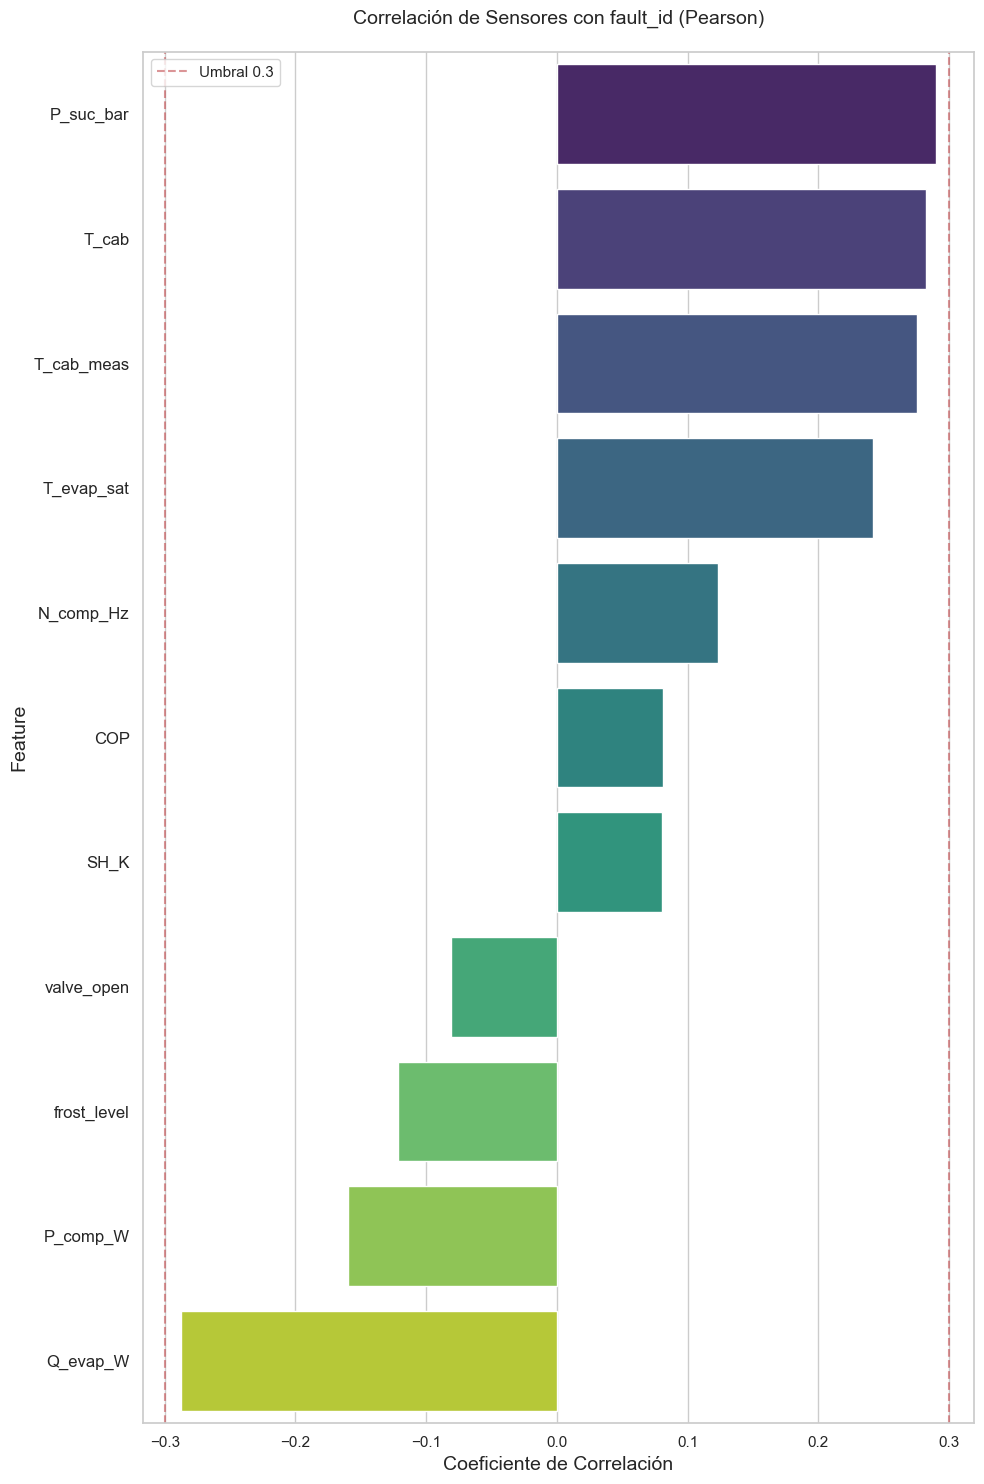

In [ ]:

plt.figure(figsize=(10, 15)) 

#Filtramos solo las variables con mas de 0.05 de colinealidad
fault_corr = fault_corr[abs(fault_corr) > 0.05] 


sns.barplot(
    x=fault_corr.values, 
    y=fault_corr.index, 
    hue=fault_corr.index, 
    palette='viridis', 
    legend=False
)


plt.yticks(fontsize=12) 
plt.title('Correlación de Sensores con fault_id (Pearson)', fontsize=14, pad=20)
plt.xlabel('Coeficiente de Correlación', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.axvline(x=0.3, color='r', linestyle='--', alpha=0.6, label='Umbral 0.3')
plt.axvline(x=-0.3, color='r', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.legend(loc='best')
plt.show()


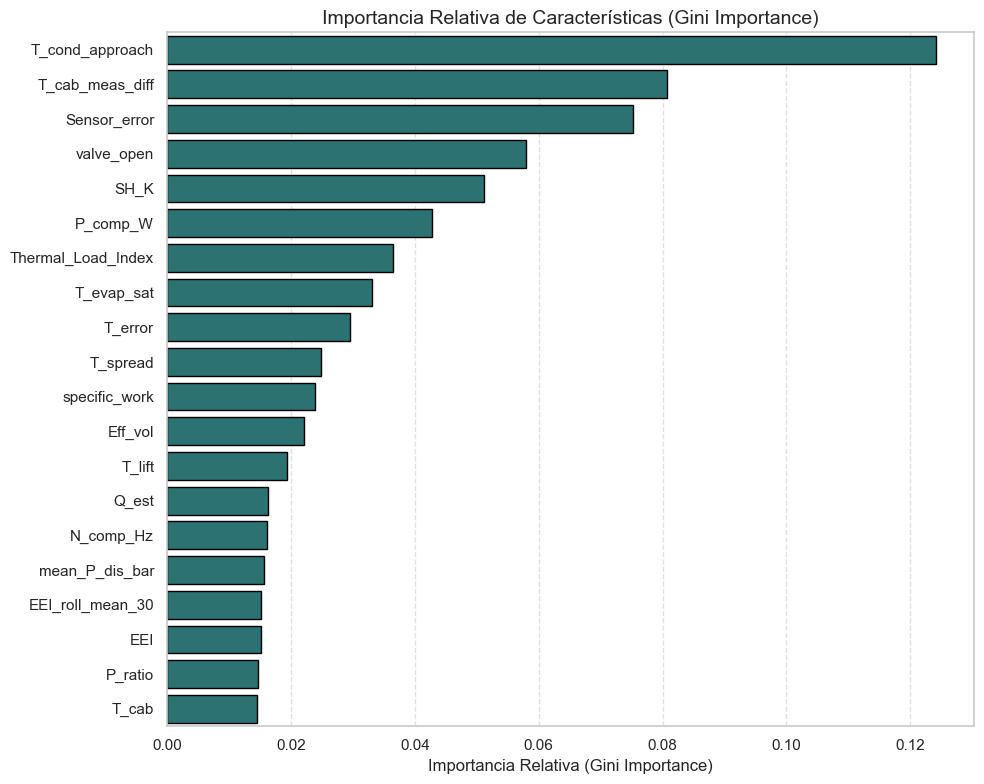

In [ ]:
#FEATURE IMPORTANCE DEL MODELO (Gini Importance) - IMPORTANTE: ESTE CÓDIGO ASUME QUE EL MODELO YA FUE ENTRENADO Y GUARDADO EN LA RUTA ESPECIFICADA. SI NO, DEBERÁS ENTRENARLO PRIMERO O AJUSTAR LA RUTA.
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


model = joblib.load('../../models/artifacts/refrigeracion_model.pkl')


feature_importances = model.feature_importances_
feature_names = model.feature_names_in_ 


importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df[importance_df['feature'] != 'T_subcooling_approx']
importance_df = importance_df.sort_values(by='importance', ascending=False)


plt.figure(figsize=(10, 8))

sns.barplot(
    x=importance_df['importance'].head(20), 
    y=importance_df['feature'].head(20), 
    color='#207d7e',  
    edgecolor='black'
)

plt.title('Importancia Relativa de Características (Gini Importance)', fontsize=14)
plt.xlabel('Importancia Relativa (Gini Importance)', fontsize=12)
plt.ylabel('', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#MULTICOLINEALIDAD (Eliminamos características que están muy relacionadas con otras)
df_final = df_final.drop(columns=['T_cond_sat', 'P_suc_bar'])

In [ ]:
# Definimos la ruta de salida
output_dir = '../../data/processed/'
if not os.path.exists(output_dir): os.makedirs(output_dir)

# GUARDAMOS EL ARCHIVO
# Este es el que usará el notebook de Evaluación para calcular umbrales físicos
path_not_scaled = os.path.join(output_dir, 'dataset_refrigeracion_processed_not_scaled.csv')
df_final.to_csv(path_not_scaled, index=False)

print(f"Proceso completado. Dataset guardado en: {path_not_scaled}")
print(f"Columnas finales: {df_final.shape[1]}")

KeyboardInterrupt: 